In [1]:
import socket, os, torch, subprocess
print("hostname:", socket.gethostname())
print("pid:", os.getpid())
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device count:", torch.cuda.device_count())
    print("current device:", torch.cuda.current_device())
    subprocess.run(["nvidia-smi", "-L"], check=False)

hostname: gilbreth-g007.rcac.purdue.edu
pid: 109159
cuda available: True
cuda device count: 1
current device: 0
GPU 0: NVIDIA A100-PCIE-40GB (UUID: GPU-690eaa5a-6bab-0c37-d625-556a9dfb5643)


### World model tests 

world model: /home/zoellner/src/guided-diffusion/models/dynamics/baseline_mlp/best_model.pt
device: cuda
run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50/dp_base


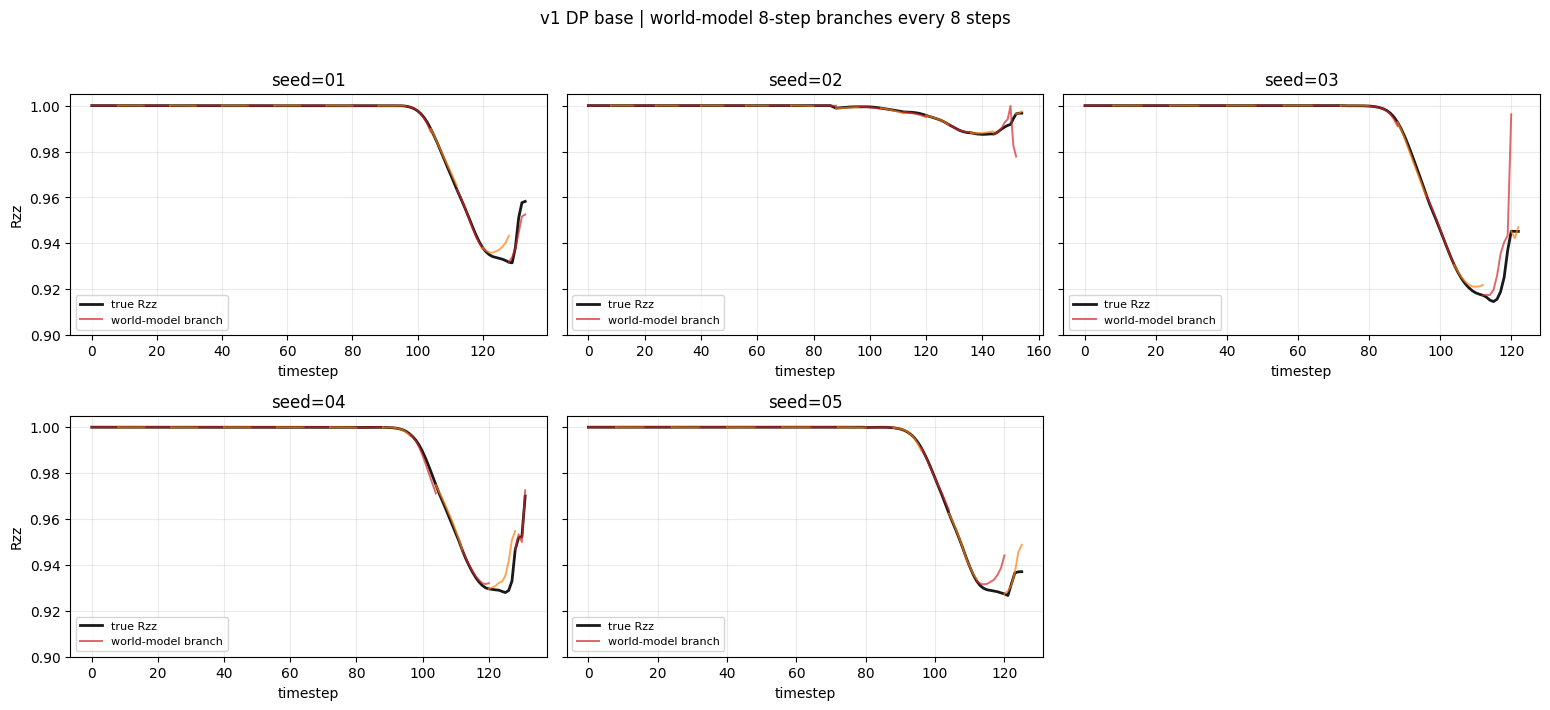

In [7]:
# Grid version: v1 DP-base seeds 1..5, one subplot per seed, compact layout.
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").exists():
    REPO_ROOT = REPO_ROOT.parent
for p in [REPO_ROOT / "experiments", REPO_ROOT / "guidance", REPO_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from diffusion_comparison import DEFAULT_WORLD_MODEL_RUN_PATH
from world_model_utils import load_model_for_eval, rzz_from_state_29d, predict_next_state_from_raw

base_dir = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison")
run_root = base_dir / "20260407_210830_v1_s1_50"
method_slug = "dp_base"
env_name = "n16h300r60g1bYfYv1"
seed_list = [1, 2, 3, 4, 5]

branch_horizon = 8
branch_stride = 8
branch_colors = ["#d62728", "#ff7f0e"]

device = "cuda" if torch.cuda.is_available() else "cpu"
predictor, stats, _, eval_meta = load_model_for_eval(
    model_or_run_path=str(DEFAULT_WORLD_MODEL_RUN_PATH),
    device=device,
    predictor_kind="learned",
    load_val_trajectories=False,
 )

print(f"world model: {eval_meta['ckpt_path']}")
print(f"device: {device}")
print(f"run root: {run_root / method_slug}")

n_methods = len(seed_list)
ncols = 3
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), sharey=True)
axes = np.atleast_1d(axes).reshape(-1)

for ax, seed in zip(axes[:n_methods], seed_list):
    npz_path = run_root / method_slug / f"{env_name}__seed_{seed:02d}" / "rollout_numeric.npz"
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing rollout file: {npz_path}")

    data = np.load(npz_path)
    states_np = np.asarray(data["states"], dtype=np.float32)
    actions_np = np.asarray(data["actions"], dtype=np.float32)
    states = [s for s in states_np]
    actions = [a for a in actions_np]

    true_rzz = np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)
    ax.plot(
        np.arange(len(true_rzz)),
        true_rzz,
        lw=2.0,
        color="black",
        alpha=0.9,
        label="true Rzz",
    )

    first_branch_label = True
    t_actions = len(actions)
    for branch_idx, t0 in enumerate(range(0, t_actions, branch_stride)):
        s_roll = np.asarray(states[t0], dtype=np.float32).copy()
        branch_rzz = [true_rzz[t0]]
        k_max = min(branch_horizon, t_actions - t0)

        for k in range(k_max):
            a_k = actions[t0 + k]
            s_roll = predict_next_state_from_raw(s_roll, a_k, predictor, stats, device)
            branch_rzz.append(rzz_from_state_29d(s_roll))

        x_branch = np.arange(t0, t0 + len(branch_rzz))
        color = branch_colors[branch_idx % len(branch_colors)]
        ax.plot(
            x_branch,
            np.asarray(branch_rzz, dtype=np.float32),
            color=color,
            lw=1.4,
            alpha=0.7,
            label="world-model branch" if first_branch_label else None,
        )
        first_branch_label = False

    ax.set_title(f"seed={seed:02d}")
    ax.set_xlabel("timestep")
    ax.set_ylim(0.90, 1.005)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, frameon=True, loc="best")

for idx, ax in enumerate(axes[:n_methods]):
    if (idx % ncols) == 0:
        ax.set_ylabel("Rzz")

for ax in axes[n_methods:]:
    ax.axis("off")

fig.suptitle("v1 DP base | world-model 8-step branches every 8 steps", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [17]:
# One-off v1 seed=05 base rollout in env, saving per-timestep init states plus obs/action traces.
from pathlib import Path
from datetime import datetime
import json
import pickle
import numpy as np
import torch

# Local imports from repo modules.
import sys
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").exists():
    REPO_ROOT = REPO_ROOT.parent
for p in [REPO_ROOT / "experiments", REPO_ROOT / "guidance", REPO_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Ensure robosuite package path and make() symbol are correctly bound.
import robosuite
robosuite_pkg_root = REPO_ROOT / "robosuite" / "robosuite"
robosuite.__file__ = str(robosuite_pkg_root / "__init__.py")
robosuite.__path__ = [str(robosuite_pkg_root)]
from robosuite.environments.base import make as robosuite_make
from robosuite.environments.manipulation.pick_place import PickPlaceCan
if not hasattr(robosuite, "make"):
    robosuite.make = robosuite_make

from diffusion_comparison import load_policy_and_env, reseed
from world_model_utils import load_init_state_json

# Match v1 base seed-05 setup.
SEED = 5
HORIZON = 300
POLICY_CKPT_PATH = Path("/scratch/gilbreth/zoellner/diffusion_runs/can_mh_lowdim/20260209180642/models/model_epoch_2000.pth")
INIT_STATE_PATH = REPO_ROOT / "outputs/can_rollouts/snr/n16h300r60g1bYfYv1/init_state.json"

if not POLICY_CKPT_PATH.exists():
    raise FileNotFoundError(f"Missing policy checkpoint: {POLICY_CKPT_PATH}")
if not INIT_STATE_PATH.exists():
    raise FileNotFoundError(f"Missing init state json: {INIT_STATE_PATH}")

out_root = REPO_ROOT / "outputs/can_rollouts/mode_2_initstates"
run_dir = out_root / f"v1_dp_base_seed05_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
env, policy, _ = load_policy_and_env(str(POLICY_CKPT_PATH), device=device, record_video=False)
init_state = load_init_state_json(str(INIT_STATE_PATH))

reseed(SEED)
policy.start_episode()
env.reset()
obs = env.reset_to(init_state)

saved_paths = []
rollout_trace = []
total_reward = 0.0
success = False
steps_executed = 0

for step_idx in range(HORIZON):
    # Save current env init-state snapshot before taking this step action.
    state_snapshot = env.get_state()
    step_path = run_dir / f"init_state_step_{step_idx:04d}.pkl"
    with step_path.open("wb") as f:
        pickle.dump(state_snapshot, f, protocol=pickle.HIGHEST_PROTOCOL)
    saved_paths.append(str(step_path))

    obs_snapshot = pickle.loads(pickle.dumps(obs, protocol=pickle.HIGHEST_PROTOCOL))
    act = policy(ob=obs_snapshot)
    act = np.asarray(act, dtype=np.float32)
    act = np.nan_to_num(act, nan=0.0, posinf=0.0, neginf=0.0)
    act = np.clip(act, -1.0, 1.0)

    next_obs, reward, done, _ = env.step(act)
    total_reward += float(reward)
    steps_executed = step_idx + 1

    status = env.is_success()
    success = bool(status.get("task", False)) if isinstance(status, dict) else bool(status)

    rollout_trace.append({
        "step_idx": int(step_idx),
        "state_path": str(step_path),
        "obs": obs_snapshot,
        "action": act.copy(),
        "reward": float(reward),
        "done": bool(done),
        "success": bool(success),
    })

    obs = next_obs
    if done or success:
        break

# Save final terminal state snapshot as well.
final_path = run_dir / f"init_state_step_{steps_executed:04d}_final.pkl"
with final_path.open("wb") as f:
    pickle.dump(env.get_state(), f, protocol=pickle.HIGHEST_PROTOCOL)
saved_paths.append(str(final_path))

trace_path = run_dir / "rollout_trace.pkl"
with trace_path.open("wb") as f:
    pickle.dump(rollout_trace, f, protocol=pickle.HIGHEST_PROTOCOL)

manifest = {
    "seed": SEED,
    "horizon_requested": HORIZON,
    "steps_executed": steps_executed,
    "success": bool(success),
    "total_reward": float(total_reward),
    "init_state_path": str(INIT_STATE_PATH),
    "policy_ckpt_path": str(POLICY_CKPT_PATH),
    "saved_initstate_count": len(saved_paths),
    "saved_initstate_files": saved_paths,
    "trace_path": str(trace_path),
    "run_dir": str(run_dir),
}
(run_dir / "rollout_manifest.json").write_text(json.dumps(manifest, indent=2))

print(f"device: {device}")
print(f"run dir: {run_dir}")
print(f"success: {success} | steps_executed: {steps_executed} | total_reward: {total_reward:.4f}")
print(f"saved init-state snapshots: {len(saved_paths)}")
print(f"saved rollout trace: {trace_path}")


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['object', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_eef_pos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []
Created environment with name PickPlaceCan
Action size is 7
============= Loaded Config =============
{
    "algo_name": "diffusion_policy",
    "experiment": {
        "name": "can_mh_lowdim",
        "validate": false,
        "logging": {
            "terminal_output_to_txt": true,
            "log_tb": true,
            "log_wandb": true,
            "wandb_proj_name": "guided_diffusion"
        },
        "save": {
            "enabled": true,
            "every_n_seconds": null,
            "every_n_epochs": 50,
            "epochs": [],
            "on_best_validation": false,
            "on_best_rollout_return": false,
            "on_best_rollout_success_rate": true
        },
   

In [23]:
# Prepare Policy rollout 

from pathlib import Path
from datetime import datetime
import json
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import imageio
import torch
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").exists():
    REPO_ROOT = REPO_ROOT.parent
for p in [REPO_ROOT / "experiments", REPO_ROOT / "guidance", REPO_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Ensure robosuite bindings are active in this kernel.
import robosuite
robosuite_pkg_root = REPO_ROOT / "robosuite" / "robosuite"
robosuite.__file__ = str(robosuite_pkg_root / "__init__.py")
robosuite.__path__ = [str(robosuite_pkg_root)]
from robosuite.environments.base import make as robosuite_make
from robosuite.environments.manipulation.pick_place import PickPlaceCan
if not hasattr(robosuite, "make"):
    robosuite.make = robosuite_make

from diffusion_comparison import load_policy_and_env, reseed

POLICY_CKPT_PATH = Path("/scratch/gilbreth/zoellner/diffusion_runs/can_mh_lowdim/20260209180642/models/model_epoch_2000.pth")
SEED = 5
HORIZON = 300

mode2_runs = sorted(glob.glob(str(REPO_ROOT / "outputs/can_rollouts/mode_2_initstates/v1_dp_base_seed05_*")))
if not mode2_runs:
    raise FileNotFoundError("No mode_2 initstate runs found.")
latest_mode2_run = Path(mode2_runs[-1])
step_state_path = latest_mode2_run / "init_state_step_0104.pkl"
if not step_state_path.exists():
    raise FileNotFoundError(f"Missing step-104 init state: {step_state_path}")

out_root = REPO_ROOT / "outputs/can_rollouts/guidance_scheduling/pick_init_state"
run_dir = out_root / f"seed05_from_step0104_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)
video_path = run_dir / "rollout_from_step0104.mp4"
snapshot_path = run_dir / "step0104_snapshot_frontview.png"

with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
# record_video=True ensures offscreen render context exists for rgb_array frames.
env, policy, _ = load_policy_and_env(str(POLICY_CKPT_PATH), device=device, record_video=True)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['object', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_eef_pos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []
Created environment with name PickPlaceCan
Action size is 7
============= Loaded Config =============
{
    "algo_name": "diffusion_policy",
    "experiment": {
        "name": "can_mh_lowdim",
        "validate": false,
        "logging": {
            "terminal_output_to_txt": true,
            "log_tb": true,
            "log_wandb": true,
            "wandb_proj_name": "guided_diffusion"
        },
        "save": {
            "enabled": true,
            "every_n_seconds": null,
            "every_n_epochs": 50,
            "epochs": [],
            "on_best_validation": false,
            "on_best_rollout_return": false,
            "on_best_rollout_success_rate": true
        },
   

ObservationKeyToModalityDict: robot0_joint_pos not found, adding robot0_joint_pos to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_pos_cos not found, adding robot0_joint_pos_cos to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_pos_sin not found, adding robot0_joint_pos_sin to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_vel not found, adding robot0_joint_vel to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_eef_quat_site not found, adding robot0_eef_quat_site to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_gripper_qvel not found, adding robot0_gripper_qvel to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: lang_emb not found, adding lang_emb to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
Observat

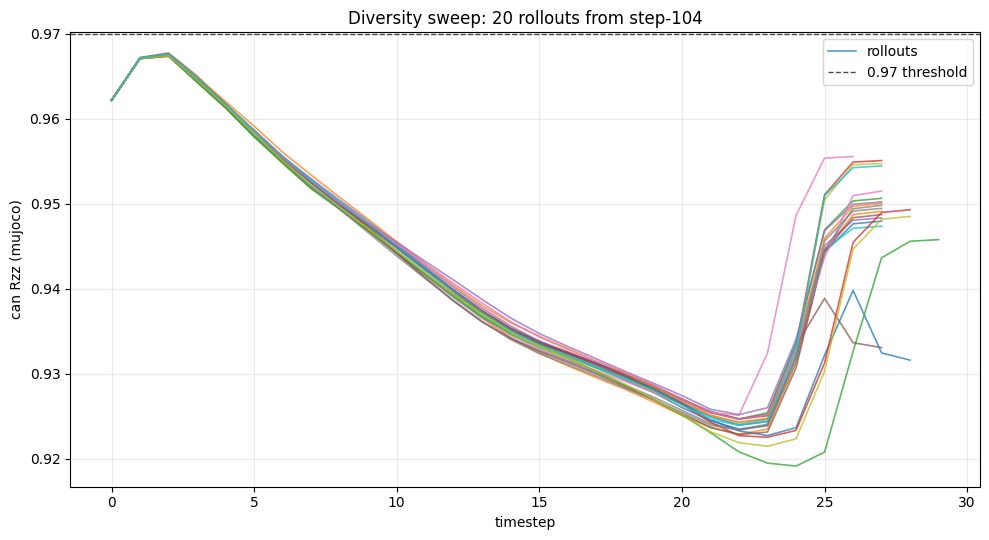

batch dir: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/diversity/seed05_from_step0104_batch_20260409_154152
num rollouts: 20 | successes: 20/20
batch manifest: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/diversity/seed05_from_step0104_batch_20260409_154152/batch_manifest.json


In [24]:
# Diversity sweep: 20 rollouts from step-104 state using step-104 trace observation as initial policy input.
from pathlib import Path
from datetime import datetime
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import imageio

from world_model_utils import get_mujoco_rzz_and_pos

NUM_ROLLOUTS = 20
TRACE_STEP_IDX = 104
DIVERSITY_ROOT = REPO_ROOT / "outputs/can_rollouts/guidance_scheduling/diversity"
batch_dir = DIVERSITY_ROOT / f"seed05_from_step0104_batch_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
batch_dir.mkdir(parents=True, exist_ok=True)

# Load initial observation from the recorded rollout trace and corresponding env state.
trace_path = latest_mode2_run / "rollout_trace.pkl"
with trace_path.open("rb") as f:
    rollout_trace = pickle.load(f)

trace_entry = next((row for row in rollout_trace if row.get("step_idx") == TRACE_STEP_IDX), None)
if trace_entry is None:
    raise ValueError(f"Could not find step {TRACE_STEP_IDX} in rollout trace: {trace_path}")

trace_obs_step = trace_entry["obs"]
if not isinstance(trace_obs_step, dict):
    raise TypeError(f"Unexpected trace obs type: {type(trace_obs_step)}")

all_rzz = []
summary_rows = []

for run_idx in range(NUM_ROLLOUTS):
    rollout_seed = int(SEED + run_idx)
    run_slug = f"rollout_{run_idx + 1:02d}"
    run_dir_i = batch_dir / run_slug
    run_dir_i.mkdir(parents=True, exist_ok=True)

    video_path_i = run_dir_i / "rollout.mp4"
    snapshot_path_i = run_dir_i / "step0104_snapshot_frontview.png"
    trace_out_path_i = run_dir_i / "obs_act_trace.pkl"
    stats_path_i = run_dir_i / "rollout_stats.json"

    reseed(rollout_seed)
    policy.start_episode()

    env.reset()
    _ = env.reset_to(init_state_step104)

    # Use the saved observation at step 104 as first observation input to policy.
    obs = pickle.loads(pickle.dumps(trace_obs_step, protocol=pickle.HIGHEST_PROTOCOL))

    frame0 = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
    imageio.imwrite(snapshot_path_i, frame0)

    writer = imageio.get_writer(str(video_path_i), fps=20)
    rzz_series = []
    obs_act_trace = []
    total_reward = 0.0
    success = False
    steps_executed = 0

    try:
        rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
        rzz_series.append(float(rzz0))
        writer.append_data(frame0)

        for step_idx in range(HORIZON):
            obs_snapshot = pickle.loads(pickle.dumps(obs, protocol=pickle.HIGHEST_PROTOCOL))
            act = policy(ob=obs_snapshot)
            act = np.asarray(act, dtype=np.float32)
            act = np.nan_to_num(act, nan=0.0, posinf=0.0, neginf=0.0)
            act = np.clip(act, -1.0, 1.0)

            next_obs, reward, done, _ = env.step(act)
            frame_t = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
            writer.append_data(frame_t)

            rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
            rzz_series.append(float(rzz_t))

            status = env.is_success()
            success = bool(status.get("task", False)) if isinstance(status, dict) else bool(status)

            obs_act_trace.append({
                "step_idx": int(step_idx),
                "obs": obs_snapshot,
                "action": act.copy(),
                "reward": float(reward),
                "done": bool(done),
                "success": bool(success),
                "can_rzz": float(rzz_t),
            })

            total_reward += float(reward)
            steps_executed = step_idx + 1

            obs = next_obs
            if done or success:
                break
    finally:
        writer.close()

    with trace_out_path_i.open("wb") as f:
        pickle.dump(obs_act_trace, f, protocol=pickle.HIGHEST_PROTOCOL)

    rollout_stats = {
        "rollout_index": int(run_idx + 1),
        "rollout_seed": int(rollout_seed),
        "source_mode2_run": str(latest_mode2_run),
        "source_step_state_path": str(step_state_path),
        "source_trace_path": str(trace_path),
        "source_trace_step_idx": int(TRACE_STEP_IDX),
        "steps_executed": int(steps_executed),
        "success": bool(success),
        "total_reward": float(total_reward),
        "initial_rzz": float(rzz_series[0]) if rzz_series else float("nan"),
        "final_rzz": float(rzz_series[-1]) if rzz_series else float("nan"),
        "video_path": str(video_path_i),
        "snapshot_path": str(snapshot_path_i),
        "obs_act_trace_path": str(trace_out_path_i),
        "run_dir": str(run_dir_i),
    }
    stats_path_i.write_text(json.dumps(rollout_stats, indent=2))

    all_rzz.append(np.asarray(rzz_series, dtype=np.float32))
    summary_rows.append(rollout_stats)

# Save batch-level metadata.
batch_manifest = {
    "num_rollouts": int(NUM_ROLLOUTS),
    "policy_ckpt_path": str(POLICY_CKPT_PATH),
    "base_seed": int(SEED),
    "horizon_requested": int(HORIZON),
    "source_mode2_run": str(latest_mode2_run),
    "source_step_state_path": str(step_state_path),
    "source_trace_path": str(trace_path),
    "source_trace_step_idx": int(TRACE_STEP_IDX),
    "batch_dir": str(batch_dir),
    "rollouts": summary_rows,
}
(batch_dir / "batch_manifest.json").write_text(json.dumps(batch_manifest, indent=2))

# Plot can-Rzz over time for all rollouts.
plt.figure(figsize=(10, 5.5))
for i, rzz in enumerate(all_rzz):
    label = "rollouts" if i == 0 else None
    plt.plot(np.arange(len(rzz)), rzz, lw=1.2, alpha=0.75, label=label)
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.7, label="0.97 threshold")
plt.xlabel("timestep")
plt.ylabel("can Rzz (mujoco)")
plt.title("Diversity sweep: 20 rollouts from step-104")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

success_count = int(sum(1 for r in summary_rows if r["success"]))
print(f"batch dir: {batch_dir}")
print(f"num rollouts: {NUM_ROLLOUTS} | successes: {success_count}/{NUM_ROLLOUTS}")
print(f"batch manifest: {batch_dir / 'batch_manifest.json'}")

attempt 01: presettle=37 steps (settled=True), drift=0.000065, slope=+1.595301e-06, steps=32, success=False, flat=True
Flatline reached at attempt 01 (tol=2.5e-04).


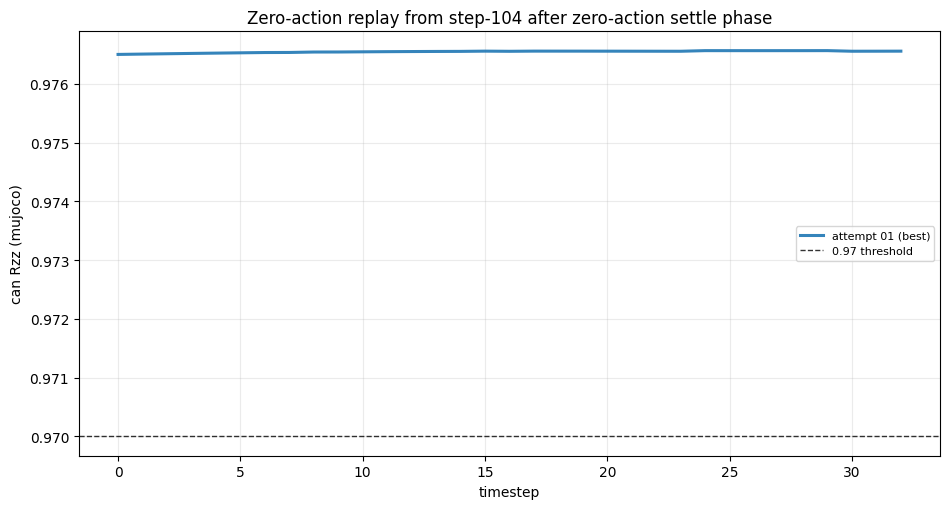

run dir: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_zero_action_flatline_20260409_162609
manifest: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_zero_action_flatline_20260409_162609/manifest.json
plot: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_zero_action_flatline_20260409_162609/zero_action_attempts_rzz.png
best attempt: 01 | drift=0.000065 | slope=+1.595301e-06
presettle: steps=37 settled=True
zero action vector: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [9]:
# Hardcoded control test: zero-action sanity check with controller re-sync until can-Rzz is flat.
from pathlib import Path
from datetime import datetime
import json
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import imageio
import torch
import sys
import mujoco

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").exists():
    REPO_ROOT = REPO_ROOT.parent
for p in [REPO_ROOT / "experiments", REPO_ROOT / "guidance", REPO_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Ensure robosuite bindings are active in this kernel.
import robosuite
robosuite_pkg_root = REPO_ROOT / "robosuite" / "robosuite"
robosuite.__file__ = str(robosuite_pkg_root / "__init__.py")
robosuite.__path__ = [str(robosuite_pkg_root)]
from robosuite.environments.base import make as robosuite_make
from robosuite.environments.manipulation.pick_place import PickPlaceCan
if not hasattr(robosuite, "make"):
    robosuite.make = robosuite_make

from diffusion_comparison import load_policy_and_env, reseed
from world_model_utils import get_mujoco_rzz_and_pos

if "SEED" not in globals():
    SEED = 5
if "POLICY_CKPT_PATH" not in globals():
    POLICY_CKPT_PATH = Path("/scratch/gilbreth/zoellner/diffusion_runs/can_mh_lowdim/20260209180642/models/model_epoch_2000.pth")

mode2_runs = sorted(glob.glob(str(REPO_ROOT / "outputs/can_rollouts/mode_2_initstates/v1_dp_base_seed05_*")))
if not mode2_runs:
    raise FileNotFoundError("No mode_2 initstate runs found.")
latest_mode2_run = Path(mode2_runs[-1])
step_state_path = latest_mode2_run / "init_state_step_0104.pkl"
if not step_state_path.exists():
    raise FileNotFoundError(f"Missing step-104 init state: {step_state_path}")

with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)

if "env" not in globals() or "policy" not in globals():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    env, policy, _ = load_policy_and_env(str(POLICY_CKPT_PATH), device=device, record_video=True)

# Experimental controls
NUM_STEPS = 32
MAX_ATTEMPTS = 6
FLAT_RZZ_TOL = 2.5e-4
ZERO_QVEL_ON_RESET = True
FORCE_ZERO_ACTION = True

# Settling controls: run zero-action burn-in before recording.
PRESETTLE_ENABLED = True
PRESETTLE_MAX_STEPS = 160
PRESETTLE_WINDOW = 10
PRESETTLE_TOL = 8e-5

out_root = REPO_ROOT / "outputs/can_rollouts/guidance_scheduling/hardcoded"
run_dir = out_root / f"step0104_zero_action_flatline_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)

def _unwrap_to_attr(root_env, attr_name, max_depth=16):
    probe = root_env
    for _ in range(max_depth):
        if hasattr(probe, attr_name):
            return probe
        if not hasattr(probe, "env"):
            break
        probe = probe.env
    return None

sim_holder = _unwrap_to_attr(env, "sim")
if sim_holder is None:
    raise RuntimeError("Could not find MuJoCo sim in env wrappers.")
sim = sim_holder.sim
sim_model = getattr(sim, "model", None)
if sim_model is None:
    sim_model = getattr(sim, "_model", None)
sim_data = getattr(sim, "data", None)
if sim_data is None:
    sim_data = getattr(sim, "_data", None)
if sim_model is None or sim_data is None:
    raise RuntimeError("Could not access MuJoCo model/data handles from sim.")

rs_holder = _unwrap_to_attr(env, "robots")
if rs_holder is None:
    raise RuntimeError("Could not find robosuite env with robots list in wrappers.")

nq = int(sim_model.nq)
nv = int(sim_model.nv)
qvel_start = 1 + nq
qvel_end = qvel_start + nv

attempt_rows = []
best_idx = None
best_drift = np.inf
all_attempt_rzz = []

for attempt_idx in range(MAX_ATTEMPTS):
    attempt_seed = int(SEED)
    reseed(attempt_seed)
    policy.start_episode()
    env.reset()

    state_for_reset = dict(init_state_step104)
    state_vec = np.asarray(init_state_step104["states"], dtype=np.float64).copy()
    qvel_norm_before = float(np.linalg.norm(state_vec[qvel_start:qvel_end]))
    if ZERO_QVEL_ON_RESET:
        state_vec[qvel_start:qvel_end] = 0.0
    state_for_reset["states"] = state_vec
    qvel_norm_after = float(np.linalg.norm(state_for_reset["states"][qvel_start:qvel_end]))

    obs = env.reset_to(state_for_reset)

    # Re-synchronize controller goals with the restored simulator state.
    for robot in getattr(rs_holder, "robots", []):
        if hasattr(robot, "composite_controller"):
            robot.composite_controller.update_state()
            robot.composite_controller.reset()

    if hasattr(sim_data, "ctrl"):
        sim_data.ctrl[:] = 0.0

    # Some bindings expose broken sim.forward(); drive forward through mujoco API directly.
    mujoco.mj_forward(sim_model._model if hasattr(sim_model, "_model") else sim_model, sim_data._data if hasattr(sim_data, "_data") else sim_data)

    template_act = np.asarray(policy(ob=obs), dtype=np.float32)
    act = np.zeros_like(template_act)
    if not FORCE_ZERO_ACTION:
        if act.shape[0] >= 5:
            act[4] = 0.05
        if act.shape[0] >= 7:
            act[6] = 1.0

    settled = False
    settle_steps = 0
    if PRESETTLE_ENABLED:
        settle_rzz = []
        for settle_idx in range(PRESETTLE_MAX_STEPS):
            obs, _, done_settle, _ = env.step(act)
            rzz_settle, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
            settle_rzz.append(float(rzz_settle))
            settle_steps = settle_idx + 1

            if len(settle_rzz) >= PRESETTLE_WINDOW:
                recent = np.asarray(settle_rzz[-PRESETTLE_WINDOW:], dtype=np.float32)
                if float(np.ptp(recent)) <= PRESETTLE_TOL:
                    settled = True
                    break
            if done_settle:
                break

    attempt_slug = f"attempt_{attempt_idx + 1:02d}"
    attempt_dir = run_dir / attempt_slug
    attempt_dir.mkdir(parents=True, exist_ok=True)
    video_path = attempt_dir / "rollout.mp4"
    trace_path = attempt_dir / "obs_act_trace.pkl"
    stats_path = attempt_dir / "rollout_stats.json"

    writer = imageio.get_writer(str(video_path), fps=20)
    rzz_series = []
    rewards = []
    obs_act_trace = []
    success = False
    steps_executed = 0

    try:
        frame0 = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
        writer.append_data(frame0)
        rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
        rzz_series.append(float(rzz0))

        for step_idx in range(NUM_STEPS):
            obs_snapshot = pickle.loads(pickle.dumps(obs, protocol=pickle.HIGHEST_PROTOCOL))
            next_obs, reward, done, _ = env.step(act)

            frame_t = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
            writer.append_data(frame_t)

            rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
            rzz_series.append(float(rzz_t))
            rewards.append(float(reward))

            status = env.is_success()
            success = bool(status.get("task", False)) if isinstance(status, dict) else bool(status)
            steps_executed = step_idx + 1

            obs_act_trace.append({
                "step_idx": int(step_idx),
                "obs": obs_snapshot,
                "action": act.copy(),
                "reward": float(reward),
                "done": bool(done),
                "success": bool(success),
                "can_rzz": float(rzz_t),
            })

            obs = next_obs
            if done or success:
                break
    finally:
        writer.close()

    with trace_path.open("wb") as f:
        pickle.dump(obs_act_trace, f, protocol=pickle.HIGHEST_PROTOCOL)

    rzz_arr = np.asarray(rzz_series, dtype=np.float32)
    drift = float(np.ptp(rzz_arr)) if len(rzz_arr) > 0 else float("inf")
    slope = float(np.polyfit(np.arange(len(rzz_arr), dtype=np.float32), rzz_arr, 1)[0]) if len(rzz_arr) >= 2 else 0.0
    is_flat = bool(drift <= FLAT_RZZ_TOL)

    stats = {
        "attempt_index": int(attempt_idx + 1),
        "source_mode2_run": str(latest_mode2_run),
        "source_step_state_path": str(step_state_path),
        "seed": int(attempt_seed),
        "num_steps_requested": int(NUM_STEPS),
        "steps_executed": int(steps_executed),
        "force_zero_action": bool(FORCE_ZERO_ACTION),
        "zero_qvel_on_reset": bool(ZERO_QVEL_ON_RESET),
        "qvel_norm_before_reset": float(qvel_norm_before),
        "qvel_norm_after_reset": float(qvel_norm_after),
        "action_template": np.asarray(act).tolist(),
        "presettle_enabled": bool(PRESETTLE_ENABLED),
        "presettle_max_steps": int(PRESETTLE_MAX_STEPS),
        "presettle_window": int(PRESETTLE_WINDOW),
        "presettle_tol": float(PRESETTLE_TOL),
        "presettle_steps_executed": int(settle_steps),
        "presettle_settled": bool(settled),
        "success": bool(success),
        "total_reward": float(np.sum(rewards) if rewards else 0.0),
        "initial_rzz": float(rzz_arr[0]) if len(rzz_arr) else float("nan"),
        "final_rzz": float(rzz_arr[-1]) if len(rzz_arr) else float("nan"),
        "rzz_drift_ptp": float(drift),
        "rzz_slope_per_step": float(slope),
        "flat_tol": float(FLAT_RZZ_TOL),
        "is_flat": bool(is_flat),
        "video_path": str(video_path),
        "trace_path": str(trace_path),
        "attempt_dir": str(attempt_dir),
    }
    stats_path.write_text(json.dumps(stats, indent=2))

    attempt_rows.append(stats)
    all_attempt_rzz.append(rzz_arr)

    if drift < best_drift:
        best_drift = drift
        best_idx = attempt_idx

    print(
        f"attempt {attempt_idx + 1:02d}: presettle={settle_steps} steps (settled={settled}), "
        f"drift={drift:.6f}, slope={slope:+.6e}, steps={steps_executed}, success={success}, flat={is_flat}"
    )

    if is_flat:
        print(f"Flatline reached at attempt {attempt_idx + 1:02d} (tol={FLAT_RZZ_TOL:.1e}).")
        break

if best_idx is None:
    raise RuntimeError("No attempts were executed.")

# Plot all attempts and emphasize the best one.
plt.figure(figsize=(9.6, 5.2))
for i, rzz in enumerate(all_attempt_rzz):
    lw = 2.2 if i == best_idx else 1.0
    alpha = 0.9 if i == best_idx else 0.45
    label = f"attempt {i + 1:02d}" + (" (best)" if i == best_idx else "")
    plt.plot(np.arange(len(rzz)), rzz, lw=lw, alpha=alpha, label=label)
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.8, label="0.97 threshold")
plt.xlabel("timestep")
plt.ylabel("can Rzz (mujoco)")
plt.title("Zero-action replay from step-104 after zero-action settle phase")
plt.grid(alpha=0.25)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plot_path = run_dir / "zero_action_attempts_rzz.png"
plt.savefig(plot_path, dpi=150)
plt.show()

manifest = {
    "source_mode2_run": str(latest_mode2_run),
    "source_step_state_path": str(step_state_path),
    "policy_ckpt_path": str(POLICY_CKPT_PATH),
    "seed": int(SEED),
    "num_steps_requested": int(NUM_STEPS),
    "max_attempts": int(MAX_ATTEMPTS),
    "flat_rzz_tol": float(FLAT_RZZ_TOL),
    "force_zero_action": bool(FORCE_ZERO_ACTION),
    "zero_qvel_on_reset": bool(ZERO_QVEL_ON_RESET),
    "presettle_enabled": bool(PRESETTLE_ENABLED),
    "presettle_max_steps": int(PRESETTLE_MAX_STEPS),
    "presettle_window": int(PRESETTLE_WINDOW),
    "presettle_tol": float(PRESETTLE_TOL),
    "attempts_executed": int(len(attempt_rows)),
    "best_attempt_index": int(best_idx + 1),
    "best_attempt_drift": float(best_drift),
    "plot_path": str(plot_path),
    "run_dir": str(run_dir),
    "attempts": attempt_rows,
}
(run_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))

best_stats = attempt_rows[best_idx]
print(f"run dir: {run_dir}")
print(f"manifest: {run_dir / 'manifest.json'}")
print(f"plot: {plot_path}")
print(f"best attempt: {best_idx + 1:02d} | drift={best_stats['rzz_drift_ptp']:.6f} | slope={best_stats['rzz_slope_per_step']:+.6e}")
print(f"presettle: steps={best_stats['presettle_steps_executed']} settled={best_stats['presettle_settled']}")
print(f"zero action vector: {best_stats['action_template']}")

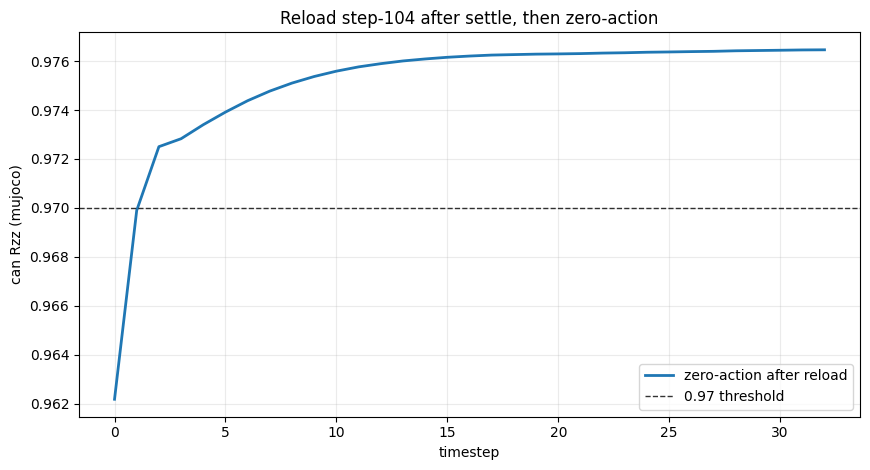

run dir: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_reload_after_settle_20260409_163030
state reload max abs err: 0.000e+00
drift=0.014287, slope=+1.851867e-04, flat=False
plot: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_reload_after_settle_20260409_163030/reload_after_settle_rzz.png
video: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_reload_after_settle_20260409_163030/reload_after_settle_zero_action.mp4
stats: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_reload_after_settle_20260409_163030/reload_after_settle_stats.json


In [10]:
# Exact-step104 test: settle first, then reload step-104 again, then measure zero-action drift.
from pathlib import Path
from datetime import datetime
import json
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import imageio
import torch
import sys
import mujoco

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").exists():
    REPO_ROOT = REPO_ROOT.parent
for p in [REPO_ROOT / "experiments", REPO_ROOT / "guidance", REPO_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import robosuite
robosuite_pkg_root = REPO_ROOT / "robosuite" / "robosuite"
robosuite.__file__ = str(robosuite_pkg_root / "__init__.py")
robosuite.__path__ = [str(robosuite_pkg_root)]
from robosuite.environments.base import make as robosuite_make
from robosuite.environments.manipulation.pick_place import PickPlaceCan
if not hasattr(robosuite, "make"):
    robosuite.make = robosuite_make

from diffusion_comparison import load_policy_and_env, reseed
from world_model_utils import get_mujoco_rzz_and_pos

SEED = int(globals().get("SEED", 5))
POLICY_CKPT_PATH = Path(globals().get(
    "POLICY_CKPT_PATH",
    "/scratch/gilbreth/zoellner/diffusion_runs/can_mh_lowdim/20260209180642/models/model_epoch_2000.pth",
))

mode2_runs = sorted(glob.glob(str(REPO_ROOT / "outputs/can_rollouts/mode_2_initstates/v1_dp_base_seed05_*")))
if not mode2_runs:
    raise FileNotFoundError("No mode_2 initstate runs found.")
latest_mode2_run = Path(mode2_runs[-1])
step_state_path = latest_mode2_run / "init_state_step_0104.pkl"
with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)

if "env" not in globals() or "policy" not in globals():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    env, policy, _ = load_policy_and_env(str(POLICY_CKPT_PATH), device=device, record_video=True)

def _unwrap_to_attr(root_env, attr_name, max_depth=16):
    probe = root_env
    for _ in range(max_depth):
        if hasattr(probe, attr_name):
            return probe
        if not hasattr(probe, "env"):
            break
        probe = probe.env
    return None

sim_holder = _unwrap_to_attr(env, "sim")
if sim_holder is None:
    raise RuntimeError("Could not find MuJoCo sim in env wrappers.")
sim = sim_holder.sim
sim_model = getattr(sim, "model", None) or getattr(sim, "_model", None)
sim_data = getattr(sim, "data", None) or getattr(sim, "_data", None)
if sim_model is None or sim_data is None:
    raise RuntimeError("Could not access MuJoCo model/data handles from sim.")

rs_holder = _unwrap_to_attr(env, "robots")
if rs_holder is None:
    raise RuntimeError("Could not find robosuite env with robots list in wrappers.")

NUM_STEPS = 32
SETTLE_STEPS = 40
ZERO_QVEL_ON_RESET = True
FLAT_TOL = 2.5e-4

out_root = REPO_ROOT / "outputs/can_rollouts/guidance_scheduling/hardcoded"
run_dir = out_root / f"step0104_reload_after_settle_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)
video_path = run_dir / "reload_after_settle_zero_action.mp4"
plot_path = run_dir / "reload_after_settle_rzz.png"
stats_path = run_dir / "reload_after_settle_stats.json"
trace_path = run_dir / "reload_after_settle_trace.pkl"

nq = int(sim_model.nq)
nv = int(sim_model.nv)
qvel_start = 1 + nq
qvel_end = qvel_start + nv

reseed(SEED)
policy.start_episode()
env.reset()

state_for_reset = dict(init_state_step104)
state_vec = np.asarray(init_state_step104["states"], dtype=np.float64).copy()
qvel_norm_before = float(np.linalg.norm(state_vec[qvel_start:qvel_end]))
if ZERO_QVEL_ON_RESET:
    state_vec[qvel_start:qvel_end] = 0.0
state_for_reset["states"] = state_vec
qvel_norm_after = float(np.linalg.norm(state_for_reset["states"][qvel_start:qvel_end]))

obs = env.reset_to(state_for_reset)
for robot in getattr(rs_holder, "robots", []):
    if hasattr(robot, "composite_controller"):
        robot.composite_controller.update_state()
        robot.composite_controller.reset()
if hasattr(sim_data, "ctrl"):
    sim_data.ctrl[:] = 0.0
mujoco.mj_forward(sim_model._model if hasattr(sim_model, "_model") else sim_model, sim_data._data if hasattr(sim_data, "_data") else sim_data)

zero_act = np.zeros_like(np.asarray(policy(ob=obs), dtype=np.float32))

# First settle pass from step-104.
for _ in range(SETTLE_STEPS):
    obs, _, done_settle, _ = env.step(zero_act)
    if done_settle:
        break

# Critical test: reload exact step-104 again after settling.
obs = env.reset_to(state_for_reset)
for robot in getattr(rs_holder, "robots", []):
    if hasattr(robot, "composite_controller"):
        robot.composite_controller.update_state()
        robot.composite_controller.reset()
if hasattr(sim_data, "ctrl"):
    sim_data.ctrl[:] = 0.0
mujoco.mj_forward(sim_model._model if hasattr(sim_model, "_model") else sim_model, sim_data._data if hasattr(sim_data, "_data") else sim_data)

state_now = env.get_state()
state_reload_err = float(np.max(np.abs(np.asarray(state_now["states"], dtype=np.float64) - np.asarray(state_for_reset["states"], dtype=np.float64))))

writer = imageio.get_writer(str(video_path), fps=20)
rzz_series = []
obs_act_trace = []
success = False
steps_executed = 0
rewards = []

try:
    frame0 = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
    writer.append_data(frame0)
    rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
    rzz_series.append(float(rzz0))

    for step_idx in range(NUM_STEPS):
        obs_snapshot = pickle.loads(pickle.dumps(obs, protocol=pickle.HIGHEST_PROTOCOL))
        next_obs, reward, done, _ = env.step(zero_act)
        frame_t = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
        writer.append_data(frame_t)

        rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
        rzz_series.append(float(rzz_t))
        rewards.append(float(reward))

        status = env.is_success()
        success = bool(status.get("task", False)) if isinstance(status, dict) else bool(status)
        steps_executed = step_idx + 1

        obs_act_trace.append({
            "step_idx": int(step_idx),
            "obs": obs_snapshot,
            "action": zero_act.copy(),
            "reward": float(reward),
            "done": bool(done),
            "success": bool(success),
            "can_rzz": float(rzz_t),
        })

        obs = next_obs
        if done or success:
            break
finally:
    writer.close()

with trace_path.open("wb") as f:
    pickle.dump(obs_act_trace, f, protocol=pickle.HIGHEST_PROTOCOL)

rzz_arr = np.asarray(rzz_series, dtype=np.float32)
drift = float(np.ptp(rzz_arr)) if len(rzz_arr) else float("nan")
slope = float(np.polyfit(np.arange(len(rzz_arr), dtype=np.float32), rzz_arr, 1)[0]) if len(rzz_arr) >= 2 else 0.0
is_flat = bool(drift <= FLAT_TOL) if np.isfinite(drift) else False

plt.figure(figsize=(8.8, 4.8))
plt.plot(np.arange(len(rzz_arr)), rzz_arr, lw=2.0, color="#1f77b4", label="zero-action after reload")
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.8, label="0.97 threshold")
plt.xlabel("timestep")
plt.ylabel("can Rzz (mujoco)")
plt.title("Reload step-104 after settle, then zero-action")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()

stats = {
    "source_mode2_run": str(latest_mode2_run),
    "source_step_state_path": str(step_state_path),
    "seed": int(SEED),
    "settle_steps_before_reload": int(SETTLE_STEPS),
    "num_steps_requested": int(NUM_STEPS),
    "steps_executed": int(steps_executed),
    "zero_qvel_on_reset": bool(ZERO_QVEL_ON_RESET),
    "qvel_norm_before_reset": float(qvel_norm_before),
    "qvel_norm_after_reset": float(qvel_norm_after),
    "state_reload_max_abs_err": float(state_reload_err),
    "zero_action": np.asarray(zero_act).tolist(),
    "success": bool(success),
    "total_reward": float(np.sum(rewards) if rewards else 0.0),
    "initial_rzz": float(rzz_arr[0]) if len(rzz_arr) else float("nan"),
    "final_rzz": float(rzz_arr[-1]) if len(rzz_arr) else float("nan"),
    "rzz_drift_ptp": float(drift),
    "rzz_slope_per_step": float(slope),
    "flat_tol": float(FLAT_TOL),
    "is_flat": bool(is_flat),
    "video_path": str(video_path),
    "plot_path": str(plot_path),
    "trace_path": str(trace_path),
    "run_dir": str(run_dir),
}
stats_path.write_text(json.dumps(stats, indent=2))

print(f"run dir: {run_dir}")
print(f"state reload max abs err: {state_reload_err:.3e}")
print(f"drift={drift:.6f}, slope={slope:+.6e}, flat={is_flat}")
print(f"plot: {plot_path}")
print(f"video: {video_path}")
print(f"stats: {stats_path}")

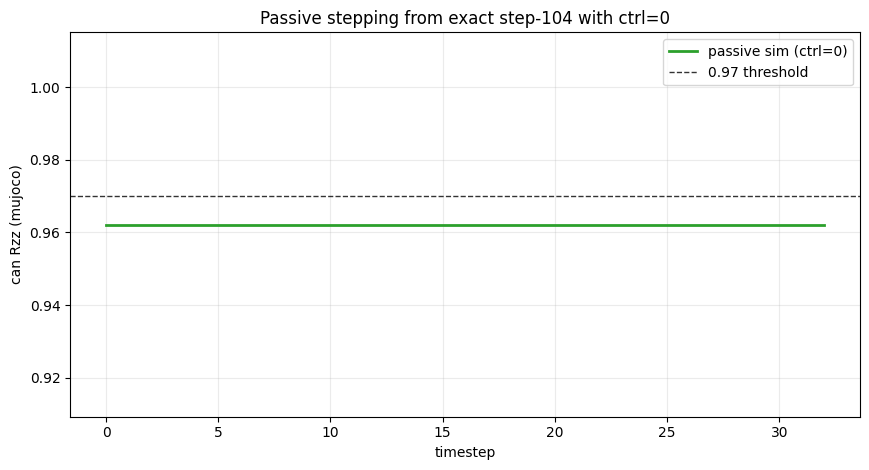

run dir: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_passive_ctrl0_20260409_163134
state reload max abs err: 0.000e+00
drift=0.000000, slope=+9.720332e-18, flat=True
plot: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_passive_ctrl0_20260409_163134/passive_ctrl0_rzz.png
video: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_passive_ctrl0_20260409_163134/passive_ctrl0.mp4
stats: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_passive_ctrl0_20260409_163134/passive_ctrl0_stats.json


In [11]:
# Passive-physics sanity: exact step-104, then step MuJoCo with ctrl=0 (no controller action pipeline).
from pathlib import Path
from datetime import datetime
import json
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import imageio
import mujoco

from world_model_utils import get_mujoco_rzz_and_pos

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").exists():
    REPO_ROOT = REPO_ROOT.parent

mode2_runs = sorted(glob.glob(str(REPO_ROOT / "outputs/can_rollouts/mode_2_initstates/v1_dp_base_seed05_*")))
if not mode2_runs:
    raise FileNotFoundError("No mode_2 initstate runs found.")
latest_mode2_run = Path(mode2_runs[-1])
step_state_path = latest_mode2_run / "init_state_step_0104.pkl"
with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)

def _unwrap_to_attr(root_env, attr_name, max_depth=16):
    probe = root_env
    for _ in range(max_depth):
        if hasattr(probe, attr_name):
            return probe
        if not hasattr(probe, "env"):
            break
        probe = probe.env
    return None

sim_holder = _unwrap_to_attr(env, "sim")
if sim_holder is None:
    raise RuntimeError("Could not find MuJoCo sim in env wrappers.")
sim = sim_holder.sim
sim_model = getattr(sim, "model", None) or getattr(sim, "_model", None)
sim_data = getattr(sim, "data", None) or getattr(sim, "_data", None)
if sim_model is None or sim_data is None:
    raise RuntimeError("Could not access MuJoCo model/data handles from sim.")

NUM_STEPS = 32
ZERO_QVEL_ON_RESET = True
FLAT_TOL = 2.5e-4

out_root = REPO_ROOT / "outputs/can_rollouts/guidance_scheduling/hardcoded"
run_dir = out_root / f"step0104_passive_ctrl0_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)
video_path = run_dir / "passive_ctrl0.mp4"
plot_path = run_dir / "passive_ctrl0_rzz.png"
stats_path = run_dir / "passive_ctrl0_stats.json"

nq = int(sim_model.nq)
nv = int(sim_model.nv)
qvel_start = 1 + nq
qvel_end = qvel_start + nv

state_for_reset = dict(init_state_step104)
state_vec = np.asarray(init_state_step104["states"], dtype=np.float64).copy()
if ZERO_QVEL_ON_RESET:
    state_vec[qvel_start:qvel_end] = 0.0
state_for_reset["states"] = state_vec

_ = env.reset_to(state_for_reset)
if hasattr(sim_data, "ctrl"):
    sim_data.ctrl[:] = 0.0
mujoco.mj_forward(sim_model._model if hasattr(sim_model, "_model") else sim_model, sim_data._data if hasattr(sim_data, "_data") else sim_data)

state_now = env.get_state()
state_reload_err = float(np.max(np.abs(np.asarray(state_now["states"], dtype=np.float64) - np.asarray(state_for_reset["states"], dtype=np.float64))))

writer = imageio.get_writer(str(video_path), fps=20)
rzz_series = []

try:
    frame0 = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
    writer.append_data(frame0)
    rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
    rzz_series.append(float(rzz0))

    for _ in range(NUM_STEPS):
        if hasattr(sim_data, "ctrl"):
            sim_data.ctrl[:] = 0.0
        mujoco.mj_step(sim_model._model if hasattr(sim_model, "_model") else sim_model, sim_data._data if hasattr(sim_data, "_data") else sim_data)

        frame_t = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
        writer.append_data(frame_t)
        rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
        rzz_series.append(float(rzz_t))
finally:
    writer.close()

rzz_arr = np.asarray(rzz_series, dtype=np.float32)
drift = float(np.ptp(rzz_arr)) if len(rzz_arr) else float("nan")
slope = float(np.polyfit(np.arange(len(rzz_arr), dtype=np.float32), rzz_arr, 1)[0]) if len(rzz_arr) >= 2 else 0.0
is_flat = bool(drift <= FLAT_TOL) if np.isfinite(drift) else False

plt.figure(figsize=(8.8, 4.8))
plt.plot(np.arange(len(rzz_arr)), rzz_arr, lw=2.0, color="#2ca02c", label="passive sim (ctrl=0)")
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.8, label="0.97 threshold")
plt.xlabel("timestep")
plt.ylabel("can Rzz (mujoco)")
plt.title("Passive stepping from exact step-104 with ctrl=0")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()

stats = {
    "source_mode2_run": str(latest_mode2_run),
    "source_step_state_path": str(step_state_path),
    "num_steps": int(NUM_STEPS),
    "zero_qvel_on_reset": bool(ZERO_QVEL_ON_RESET),
    "state_reload_max_abs_err": float(state_reload_err),
    "rzz_drift_ptp": float(drift),
    "rzz_slope_per_step": float(slope),
    "flat_tol": float(FLAT_TOL),
    "is_flat": bool(is_flat),
    "plot_path": str(plot_path),
    "video_path": str(video_path),
    "run_dir": str(run_dir),
}
stats_path.write_text(json.dumps(stats, indent=2))

print(f"run dir: {run_dir}")
print(f"state reload max abs err: {state_reload_err:.3e}")
print(f"drift={drift:.6f}, slope={slope:+.6e}, flat={is_flat}")
print(f"plot: {plot_path}")
print(f"video: {video_path}")
print(f"stats: {stats_path}")

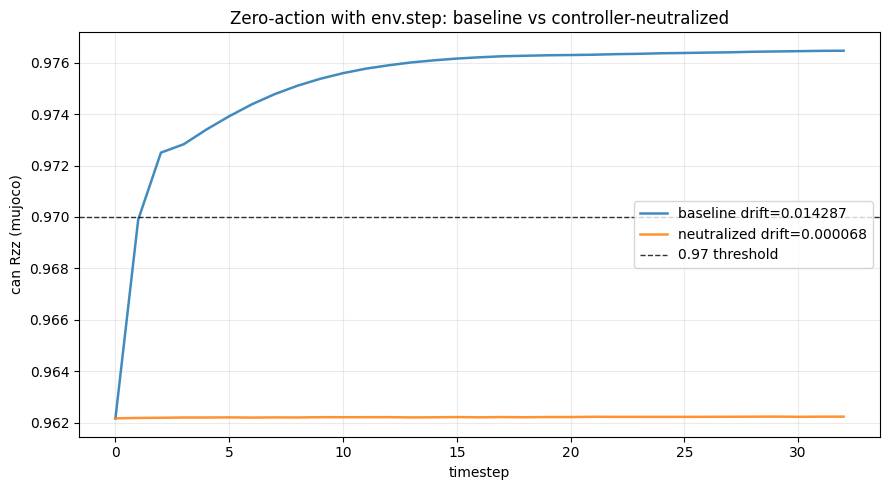

run dir: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_controller_neutralize_20260409_163535
baseline: drift=0.014287, slope=+1.851867e-04, flat=False
neutralized: drift=0.000068, slope=+1.470354e-06, flat=True
plot: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_controller_neutralize_20260409_163535/baseline_vs_neutralized_rzz.png
stats: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/hardcoded/step0104_controller_neutralize_20260409_163535/baseline_vs_neutralized_stats.json


In [12]:
# Controller-state neutralization test: keep env.step pipeline, but zero out controller startup drift.
from pathlib import Path
from datetime import datetime
import json
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import imageio
import mujoco

from world_model_utils import get_mujoco_rzz_and_pos

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").exists():
    REPO_ROOT = REPO_ROOT.parent

mode2_runs = sorted(glob.glob(str(REPO_ROOT / "outputs/can_rollouts/mode_2_initstates/v1_dp_base_seed05_*")))
if not mode2_runs:
    raise FileNotFoundError("No mode_2 initstate runs found.")
latest_mode2_run = Path(mode2_runs[-1])
step_state_path = latest_mode2_run / "init_state_step_0104.pkl"
with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)

def _unwrap_to_attr(root_env, attr_name, max_depth=16):
    probe = root_env
    for _ in range(max_depth):
        if hasattr(probe, attr_name):
            return probe
        if not hasattr(probe, "env"):
            break
        probe = probe.env
    return None

def _neutralize_controller_startup(rs_env):
    # Align controller internal goals / nullspace targets to current achieved state.
    for robot in getattr(rs_env, "robots", []):
        if hasattr(robot, "composite_controller"):
            robot.composite_controller.update_state()

        part_map = getattr(robot, "part_controllers", {})
        for part_name, ctrl in part_map.items():
            if hasattr(ctrl, "update"):
                try:
                    ctrl.update(force=True)
                except TypeError:
                    ctrl.update()

            if hasattr(ctrl, "joint_pos") and hasattr(ctrl, "update_initial_joints"):
                ctrl.update_initial_joints(np.array(ctrl.joint_pos))

            if hasattr(ctrl, "set_goal_update_mode"):
                ctrl.set_goal_update_mode("achieved")

            if hasattr(ctrl, "reset_goal"):
                try:
                    ctrl.reset_goal(goal_update_mode="achieved")
                except TypeError:
                    ctrl.reset_goal()

        if hasattr(robot, "composite_controller"):
            robot.composite_controller.reset()

sim_holder = _unwrap_to_attr(env, "sim")
if sim_holder is None:
    raise RuntimeError("Could not find MuJoCo sim in env wrappers.")
sim = sim_holder.sim
sim_model = getattr(sim, "model", None) or getattr(sim, "_model", None)
sim_data = getattr(sim, "data", None) or getattr(sim, "_data", None)
if sim_model is None or sim_data is None:
    raise RuntimeError("Could not access MuJoCo model/data handles from sim.")

rs_holder = _unwrap_to_attr(env, "robots")
if rs_holder is None:
    raise RuntimeError("Could not find robosuite env with robots list in wrappers.")

SEED = int(globals().get("SEED", 5))
NUM_STEPS = 32
ZERO_QVEL_ON_RESET = True
FLAT_TOL = 2.5e-4

out_root = REPO_ROOT / "outputs/can_rollouts/guidance_scheduling/hardcoded"
run_dir = out_root / f"step0104_controller_neutralize_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)

nq = int(sim_model.nq)
nv = int(sim_model.nv)
qvel_start = 1 + nq
qvel_end = qvel_start + nv

state_for_reset = dict(init_state_step104)
state_vec = np.asarray(init_state_step104["states"], dtype=np.float64).copy()
if ZERO_QVEL_ON_RESET:
    state_vec[qvel_start:qvel_end] = 0.0
state_for_reset["states"] = state_vec

def run_trial(neutralize=False, label="baseline"):
    reseed(SEED)
    policy.start_episode()
    env.reset()
    obs = env.reset_to(state_for_reset)

    if neutralize:
        _neutralize_controller_startup(rs_holder)

    if hasattr(sim_data, "ctrl"):
        sim_data.ctrl[:] = 0.0
    mujoco.mj_forward(sim_model._model if hasattr(sim_model, "_model") else sim_model, sim_data._data if hasattr(sim_data, "_data") else sim_data)

    zero_act = np.zeros_like(np.asarray(policy(ob=obs), dtype=np.float32))

    video_path = run_dir / f"{label}.mp4"
    writer = imageio.get_writer(str(video_path), fps=20)
    rzz_series = []

    try:
        frame0 = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
        writer.append_data(frame0)
        rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
        rzz_series.append(float(rzz0))

        for _ in range(NUM_STEPS):
            obs, _, done, _ = env.step(zero_act)
            frame_t = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
            writer.append_data(frame_t)
            rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
            rzz_series.append(float(rzz_t))
            if done:
                break
    finally:
        writer.close()

    arr = np.asarray(rzz_series, dtype=np.float32)
    drift = float(np.ptp(arr)) if len(arr) else float("nan")
    slope = float(np.polyfit(np.arange(len(arr), dtype=np.float32), arr, 1)[0]) if len(arr) >= 2 else 0.0
    return {
        "label": label,
        "neutralize": bool(neutralize),
        "video_path": str(video_path),
        "rzz": arr,
        "drift": drift,
        "slope": slope,
        "is_flat": bool(drift <= FLAT_TOL) if np.isfinite(drift) else False,
    }

baseline = run_trial(neutralize=False, label="baseline_env_step_zero_action")
neutral = run_trial(neutralize=True, label="neutralized_env_step_zero_action")

plt.figure(figsize=(9.0, 5.0))
plt.plot(np.arange(len(baseline["rzz"])), baseline["rzz"], lw=1.8, alpha=0.85, label=f"baseline drift={baseline['drift']:.6f}")
plt.plot(np.arange(len(neutral["rzz"])), neutral["rzz"], lw=1.8, alpha=0.85, label=f"neutralized drift={neutral['drift']:.6f}")
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.8, label="0.97 threshold")
plt.xlabel("timestep")
plt.ylabel("can Rzz (mujoco)")
plt.title("Zero-action with env.step: baseline vs controller-neutralized")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plot_path = run_dir / "baseline_vs_neutralized_rzz.png"
plt.savefig(plot_path, dpi=150)
plt.show()

stats = {
    "source_mode2_run": str(latest_mode2_run),
    "source_step_state_path": str(step_state_path),
    "seed": int(SEED),
    "num_steps": int(NUM_STEPS),
    "zero_qvel_on_reset": bool(ZERO_QVEL_ON_RESET),
    "flat_tol": float(FLAT_TOL),
    "baseline": {
        "drift": float(baseline["drift"]),
        "slope": float(baseline["slope"]),
        "is_flat": bool(baseline["is_flat"]),
        "video_path": baseline["video_path"],
    },
    "neutralized": {
        "drift": float(neutral["drift"]),
        "slope": float(neutral["slope"]),
        "is_flat": bool(neutral["is_flat"]),
        "video_path": neutral["video_path"],
    },
    "plot_path": str(plot_path),
    "run_dir": str(run_dir),
}
stats_path = run_dir / "baseline_vs_neutralized_stats.json"
stats_path.write_text(json.dumps(stats, indent=2))

print(f"run dir: {run_dir}")
print(f"baseline: drift={baseline['drift']:.6f}, slope={baseline['slope']:+.6e}, flat={baseline['is_flat']}")
print(f"neutralized: drift={neutral['drift']:.6f}, slope={neutral['slope']:+.6e}, flat={neutral['is_flat']}")
print(f"plot: {plot_path}")
print(f"stats: {stats_path}")